In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf, gammainc
from matplotlib import rcParams

rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 12


def lognormal_cdf(x, mu):
    """
    Lognormal CDF with amplitude A, mu, and sigma.
    
    Parameters
    ----------
    x : array-like
        The input variable (x > 0).
    mu : float
        Mean of the log.
    sigma : float
        Standard deviation of the log.
        
    Returns
    -------
    array-like
        The value of the cumulative lognormal function at each x.
    """
    sigma = 1.8 * np.log(mu+1)
    return 100 * 0.5 * (1 + erf((np.log(x) - mu) / (sigma * np.sqrt(2.0))))


def exponential_cdf(x, lamb):
    """
    Exponential CDF with amplitude A and rate lamb.
    
    Parameters
    ----------
    x : array-like
        The input variable (x >= 0).
    lamb : float
        Rate parameter.
        
    Returns
    -------
    array-like
        The value of the cumulative exponential function at each x.
    """
    return 100 * (1 - np.exp(-lamb * x))

def gamma_cdf(x, theta):
    """
    Gamma CDF with amplitude A, shape k, and scale theta.
    
    Parameters
    ----------
    x : array-like
        The input variable (x >= 0).
    k : float
        Shape parameter (> 0).
    theta : float
        Scale parameter (> 0).
        
    Returns
    -------
    array-like
        The value of the cumulative Gamma function at each x.
    """
    # gammainc returns the normalized lower incomplete gamma function.
    k = 0.5
    return 100 * gammainc(k, x / theta)

def fit_pdf(pdf_func, x, y):
    x_fit = np.linspace(0.5, 110, 200)  # a finer grid for plotting

    if pdf_func == 'lognormal':
        p0 = [1.0]  # mu=1, sigma=1, for example

        popt, pcov = curve_fit(lognormal_cdf, x, y, p0=p0)

        mu_fit, = popt
        print(f"{pdf_func} parameters:")
        print(f"  mu    = {mu_fit:.4f}")

        y_fit = lognormal_cdf(x_fit, *popt)

        y_pred = lognormal_cdf(x, *popt)

    elif pdf_func == 'exponential':

        # Initial guess: lamb=some rate
        p0 = [0.1]

        # Fit
        popt, pcov = curve_fit(exponential_cdf, x, y, p0=p0)
        lamb_fit, = popt
        print(f"{pdf_func} parameters:")
        print(f"  lamb  = {lamb_fit:.6g}")

        y_fit = exponential_cdf(x_fit, *popt)

        y_pred = exponential_cdf(x, *popt)

    elif pdf_func == 'gamma':
        # Initial guesses for A, k, and theta
        # Adjust them based on your knowledge of the data
        p0 = [2.0]  # k=2, theta=2

        # Fit the gamma PDF to the data
        popt, pcov = curve_fit(gamma_cdf, x, y, p0=p0)
        theta_fit, = popt

        print(f"{pdf_func} parameters:")
        print(f"  theta  = {theta_fit:.6g}")

        y_fit = gamma_cdf(x_fit, *popt)

        y_pred = gamma_cdf(x, *popt)

    # Calculate R^2 of the fit
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    return x_fit, y_fit, r2

lognormal parameters:
  mu    = 0.8854
exponential parameters:
  lamb  = 0.494732
gamma parameters:
  theta  = 39.0175
lognormal parameters:
  mu    = 1.9145
exponential parameters:
  lamb  = 0.0726942
gamma parameters:
  theta  = 208.187


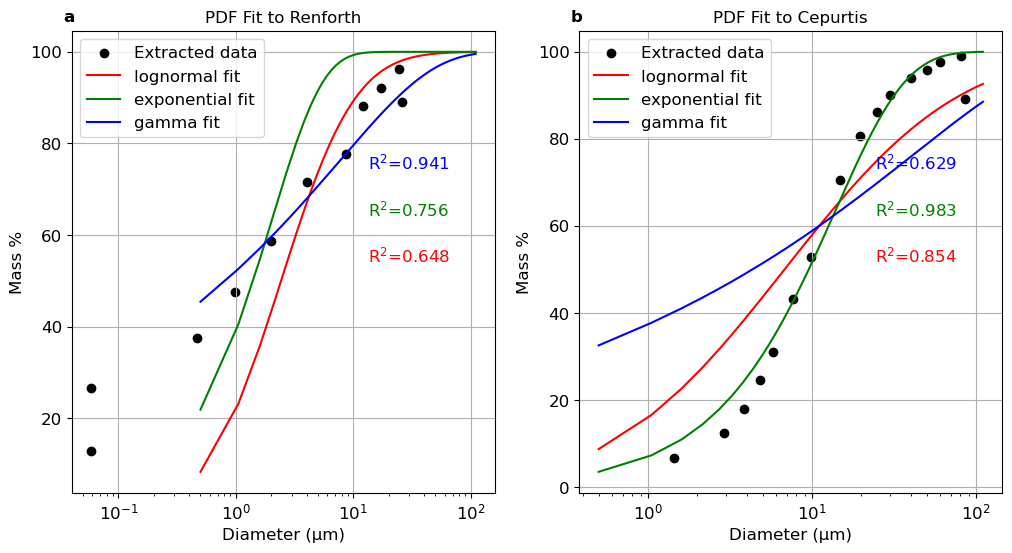

In [4]:
# 2) Approximate data from the plot (as above):
data = {
    'Renforth': {'x': np.array([0.058885942, 0.058885942, 0.465517241, 0.988328912, 1.975862069, 
                                4.009018568, 8.598143236, 12.19973475, 17.31167109, 24.39867374, 
                                25.73474801]),
                 'y': np.array([26.73496422, 12.83020232, 37.52932483, 47.68914101, 58.76652178, 
                                71.59658813, 77.78712525, 88.11372698, 92.17472453, 96.34734637, 
                                89.12165407])
    },
    'Cepurtis': {'x': np.array([1.447978096, 2.89448393, 3.856597232, 4.817187257, 5.778022093, 
                                7.700752622, 9.820938068, 14.8386704, 19.47849376, 24.70624805, 
                                29.93620565, 39.81942411, 50.28709171, 60.17313911, 80.52995507,
                                85.7780832]),
                 'y': np.array([6.672493456, 12.45360076, 17.98228407, 24.65799576, 31.1493636,
                                43.33327595, 52.83363478, 70.48119191, 80.69420007, 86.19521956, 
                                90.03714443, 93.97364856, 95.81994317, 97.62625173, 98.94383285, 
                                89.10334778])
    }
}

# 4) Curve fitting
labs = 'ab'
fig, axes = plt.subplots(1, 2, figsize = (12, 6))
for i, subset in enumerate(data.keys()):
    ax = axes.flat[i]

    # Empirical CDF
    x_data = data[subset]['x']
    y_data = data[subset]['y']

    # Plot
    ax.scatter(x_data, y_data, color='k', label='Extracted data')

    for j, (pdf, color) in enumerate(zip(['lognormal', 'exponential', 'gamma'], 
                                         ['r','g','b'])):

        x_fit, y_fit, r2 = fit_pdf(pdf, x_data, y_data)
        ax.plot(x_fit, y_fit, '-', color = color, label=f'{pdf} fit')
        ax.text(0.7, 0.5+0.1*j, 'R$^2$=' + f'{r2:.3f}', color = color, transform = ax.transAxes)

    ax.set_xscale('log')
    ax.set_xlabel('Diameter (µm)')
    ax.set_ylabel('Mass %')
    ax.set_title(f'PDF Fit to {subset}')
    ax.legend()
    ax.grid(True)
    ax.text(-0.02, 1.02, labs[i], fontdict={'weight':'bold'}, transform=ax.transAxes)